<a href="https://colab.research.google.com/github/Udit587/UditVashisht-EDA-Project/blob/main/Phase1_EDA_USSeatBelts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis — Phase 1
## US Seat Belts Dataset (1983–1997)

**Course Project — Phase 1 (5 marks)**

This notebook performs Phase 1 of the EDA course project on the **US Seat Belts** dataset,
a state-level panel dataset (50 US states + Washington DC, 1983–1997) tracking road-traffic
fatality rates alongside seat-belt usage, speed-limit laws, minimum drinking-age laws, and
economic/demographic indicators.

**Tasks covered in this notebook:**
1. Loading the dataset
2. Basic statistical analysis
3. Handling missing data
4. Data cleaning
5. Data transformation
6. Univariate analysis (≥ 3 visualizations)
7. Bivariate analysis (≥ 3 visualizations)
8. Multivariate analysis (≥ 3 visualizations)

---


## 0. Setup — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)


## 1. Loading the Dataset

The dataset is loaded directly from the raw GitHub URL so the notebook is fully
reproducible without any local file dependency.


In [3]:
DATA_URL = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/USSeatBelts.csv"
df = pd.read_csv(DATA_URL)

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (765, 13)


,rownames,state,year,miles,fatalities,seatbelt,speed65,speed70,drinkage,alcohol,income,age,enforce
0,1,AK,1983,3358,0.044669,NaN,no,no,yes,no,17973,28.234966,no
1,2,AK,1984,3589,0.037336,NaN,no,no,yes,no,18093,28.343542,no
2,3,AK,1985,3840,0.033073,NaN,no,no,yes,no,18925,28.372816,no
3,4,AK,1986,4008,0.025200,NaN,no,no,yes,no,18466,28.396652,no
4,5,AK,1987,3900,0.019487,NaN,no,no,yes,no,18021,28.453251,no


In [4]:
# Structural overview: column names, data types, non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 765 entries, 0 to 764
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rownames    765 non-null    int64  
 1   state       765 non-null    object 
 2   year        765 non-null    int64  
 3   miles       765 non-null    int64  
 4   fatalities  765 non-null    float64
 5   seatbelt    556 non-null    float64
 6   speed65     765 non-null    object 
 7   speed70     765 non-null    object 
 8   drinkage    765 non-null    object 
 9   alcohol     765 non-null    object 
 10  income      765 non-null    int64  
 11  age         765 non-null    float64
 12  enforce     765 non-null    object 
dtypes: float64(3), int64(4), object(6)
memory usage: 77.8+ KB


**Column description**

| Column | Meaning |
|---|---|
| `rownames` | Row index carried over from the source R dataset (not useful for analysis) |
| `state` | US state abbreviation (categorical) |
| `year` | Year of observation, 1983–1997 |
| `miles` | Vehicle-miles travelled in the state (millions) |
| `fatalities` | Traffic fatality rate |
| `seatbelt` | Observed seat-belt usage rate (fraction) — often missing before usage was measured |
| `speed65` / `speed70` | Whether a 65/70 mph speed limit was in force (`yes`/`no`) |
| `drinkage` | Whether the minimum legal drinking age was 21 (`yes`/`no`) |
| `alcohol` | Whether an alcohol-related law (e.g. per se law) was in effect |
| `income` | Per-capita income (USD) |
| `age` | Average age of the state's population |
| `enforce` | Type of seat-belt law enforcement: `no`, `primary`, or `secondary` |


## 2. Basic Statistical Analysis

We look at central tendency, spread, and the distribution of both numerical and
categorical variables before doing anything else, to understand the shape and scale
of the data.


In [5]:
# Descriptive statistics for numerical columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
rownames,765.0,383.000000,220.980768,1.000000,192.000000,383.000000,574.000000,765.000000
year,765.0,1990.000000,4.323320,1983.000000,1986.000000,1990.000000,1994.000000,1997.000000
miles,765.0,41447.734641,43961.990037,3099.000000,11401.000000,30319.000000,52312.000000,285612.000000
fatalities,765.0,0.021490,0.006171,0.008327,0.017341,0.021199,0.024774,0.045470
seatbelt,556.0,0.528852,0.170186,0.060000,0.420000,0.550000,0.650000,0.870000
income,765.0,17992.586928,4811.459296,8372.000000,14266.000000,17624.000000,21080.000000,35863.000000
age,765.0,35.137194,1.698131,28.234966,34.387501,35.391766,36.130787,39.169582


In [6]:
# Descriptive summary for categorical columns
df.describe(include="object").T


,count,unique,top,freq
state,765,51,AK,15
speed65,765,2,yes,494
speed70,765,2,no,711
drinkage,765,2,yes,677
alcohol,765,2,no,676
enforce,765,3,secondary,379


In [7]:
# Unique categories for each categorical column
categorical_cols = ["state", "speed65", "speed70", "drinkage", "alcohol", "enforce"]
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values -> {sorted(df[col].dropna().unique())}")


state: 51 unique values -> ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
speed65: 2 unique values -> ['no', 'yes']
speed70: 2 unique values -> ['no', 'yes']
drinkage: 2 unique values -> ['no', 'yes']
alcohol: 2 unique values -> ['no', 'yes']
enforce: 3 unique values -> ['no', 'primary', 'secondary']


In [8]:
# Correlation among numeric variables (quick first look)
numeric_cols = ["miles", "fatalities", "seatbelt", "income", "age"]
df[numeric_cols].corr().round(3)


,miles,fatalities,seatbelt,income,age
miles,1.000,-0.161,0.207,0.206,0.083
fatalities,-0.161,1.000,-0.403,-0.704,-0.375
seatbelt,0.207,-0.403,1.000,0.622,0.159
income,0.206,-0.704,0.622,1.000,0.408
age,0.083,-0.375,0.159,0.408,1.000


**Observations so far:**
- `fatalities` values are small decimals (a *rate*, not a raw count), roughly in the
  0.008–0.055 range.
- `income` and `age` both trend upward across the years for most states, as expected.
- `seatbelt` has a much smaller count than the other numeric columns in `df.info()`,
  which tells us it has a substantial number of missing values — investigated next.


## 3. Handling Missing Data

### 3.1 Identify missing values


In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_%", ascending=False)


,missing_count,missing_%
seatbelt,209,27.32


In [10]:
# Visualize *where* the missingness occurs for the two affected columns, by year
missing_by_year = df.groupby("year")[["seatbelt", "speed65"]].apply(lambda x: x.isnull().mean())
missing_by_year


,seatbelt,speed65
year,,
1983,0.941176,0.0
1984,0.843137,0.0
1985,0.568627,0.0
1986,0.450980,0.0
1987,0.450980,0.0
1988,0.431373,0.0
1989,0.411765,0.0
1990,0.000000,0.0
1991,0.000000,0.0


### 3.2 Why the data is missing (Missing Data Mechanism)

The check above shows `seatbelt` is missing almost entirely in the **early years**
(1983–1987) and becomes far more complete afterwards. This is because most US states
did not have seat-belt laws — or did not measure/report usage — until the
mid-to-late 1980s. In other words, this is **not random missingness (MCAR)**; it is
**Missing At Random / structurally missing (MAR)**, tied directly to `year` and `state`.

Because of this, a single global fill value (like the overall mean) would be
misleading — it would imply a usage rate existed when it simply wasn't being tracked yet.
The more defensible approach is **group-wise imputation by state**, since seat-belt
adoption trends are state-specific and gradual over time.

`speed70` has almost no missing values and can be handled trivially. `speed65` has a
handful of missing rows following the same early-years pattern.

### 3.3 Apply imputation


In [11]:
# Group-wise (per-state) median imputation for seatbelt and speed65-adjacent numeric gaps.
df["seatbelt"] = df.groupby("state")["seatbelt"].transform(lambda x: x.fillna(x.median()))

# A few states may still have all-NaN seatbelt histories in the earliest years covered by
df["seatbelt"] = df["seatbelt"].fillna(0)

# Confirm no missing values remain
df.isnull().sum().sum()


np.int64(0)

In [12]:
print("Missing values remaining in the dataset:", df.isnull().sum().sum())


Missing values remaining in the dataset: 0


## 4. Data Cleaning

Now that missing values are resolved, we clean up structural issues in the data:
redundant columns, duplicate rows, data types, and category label formatting.


In [13]:
# 4.1 Drop the redundant index column carried over from the source file
df = df.drop(columns=["rownames"])

# 4.2 Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [14]:
# 4.3 Correct data types
df["year"] = df["year"].astype(int)

# Yes/no fields and enforcement type are categorical, not free text
for col in ["speed65", "speed70", "drinkage", "alcohol", "enforce", "state"]:
    df[col] = df[col].astype("category")

df.dtypes


,0
state,category
year,int64
miles,int64
fatalities,float64
seatbelt,float64
speed65,category
speed70,category
drinkage,category
alcohol,category
income,int64


In [15]:
# 4.4 Sanity-check numeric ranges for implausible values (e.g. negative income, fatality rate > 1)
df[["miles", "fatalities", "seatbelt", "income", "age"]].agg(["min", "max"])


,miles,fatalities,seatbelt,income,age
min,3099,0.008327,0.06,8372,28.234966
max,285612,0.045470,0.87,35863,39.169582


No negative values, no seat-belt usage rate above 1, and no fatality rate above 1 —
the data passes basic plausibility checks. No rows need to be dropped as outliers at
this stage; extreme values look like genuine state-level variation (e.g. very high
mileage for large states like `CA`/`TX`), which we'll examine visually in the sections
below rather than removing blindly.


## 5. Data Transformation

We now engineer a few derived features that will make the upcoming visual analysis
clearer, and prepare a scaled version of the numeric features for any future
modelling phase.


In [16]:
# 5.1 Bin 'year' into 5-year eras, which is easier to read on plots than 15 individual years
df["year_group"] = pd.cut(
    df["year"],
    bins=[1982, 1987, 1992, 1997],
    labels=["1983-1987", "1988-1992", "1993-1997"]
)

# 5.2 Bin income into Low / Medium / High terciles for easier categorical comparison
df["income_level"] = pd.qcut(df["income"], q=3, labels=["Low", "Medium", "High"])

# 5.3 Consolidate whether *any* seat-belt enforcement law existed (binary flag)
df["has_enforcement_law"] = (df["enforce"] != "no").map({True: "yes", False: "no"})

df[["year", "year_group", "income", "income_level", "enforce", "has_enforcement_law"]].head()


,year,year_group,income,income_level,enforce,has_enforcement_law
0,1983,1983-1987,17973,Medium,no,no
1,1984,1983-1987,18093,Medium,no,no
2,1985,1983-1987,18925,Medium,no,no
3,1986,1983-1987,18466,Medium,no,no
4,1987,1983-1987,18021,Medium,no,no


In [17]:
# 5.4 Standardize numeric features (mean 0, std 1) — useful preparation for later
# modelling phases (Phase 2/3), stored in new columns so raw values are preserved.
scaler = StandardScaler()
scaled_cols = ["miles", "fatalities", "seatbelt", "income", "age"]
scaled_values = scaler.fit_transform(df[scaled_cols])
scaled_df = pd.DataFrame(scaled_values, columns=[f"{c}_scaled" for c in scaled_cols], index=df.index)

df = pd.concat([df, scaled_df], axis=1)
df.head()


,state,year,miles,fatalities,seatbelt,speed65,speed70,drinkage,alcohol,income,age,enforce,year_group,income_level,has_enforcement_law,miles_scaled,fatalities_scaled,seatbelt_scaled,income_scaled,age_scaled
0,AK,1983,3358,0.044669,0.69,no,no,yes,no,17973,28.234966,no,1983-1987,Medium,no,-0.866991,3.758546,0.953251,-0.004074,-4.067261
1,AK,1984,3589,0.037336,0.69,no,no,yes,no,18093,28.343542,no,1983-1987,Medium,no,-0.861733,2.569503,0.953251,0.020883,-4.003280
2,AK,1985,3840,0.033073,0.69,no,no,yes,no,18925,28.372816,no,1983-1987,Medium,no,-0.856020,1.878209,0.953251,0.193917,-3.986030
3,AK,1986,4008,0.025200,0.69,no,no,yes,no,18466,28.396652,no,1983-1987,Medium,no,-0.852196,0.601578,0.953251,0.098457,-3.971984
4,AK,1987,3900,0.019487,0.69,no,no,yes,no,18021,28.453251,no,1983-1987,Medium,no,-0.854654,-0.324672,0.953251,0.005909,-3.938633


## 6. Univariate Analysis

Examining the distribution of individual variables of interest, one at a time.


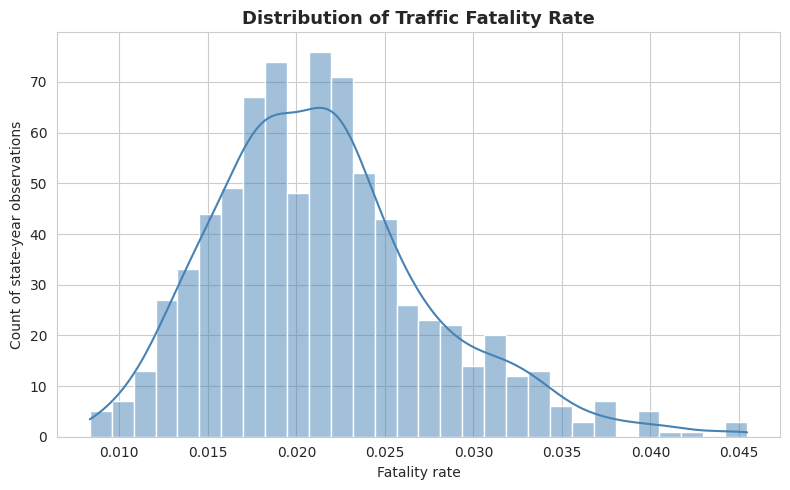

In [18]:
# 6.1 Distribution of the fatality rate
fig, ax = plt.subplots()
sns.histplot(df["fatalities"], bins=30, kde=True, color="steelblue", ax=ax)
ax.set_title("Distribution of Traffic Fatality Rate")
ax.set_xlabel("Fatality rate")
ax.set_ylabel("Count of state-year observations")
plt.tight_layout()
plt.show()


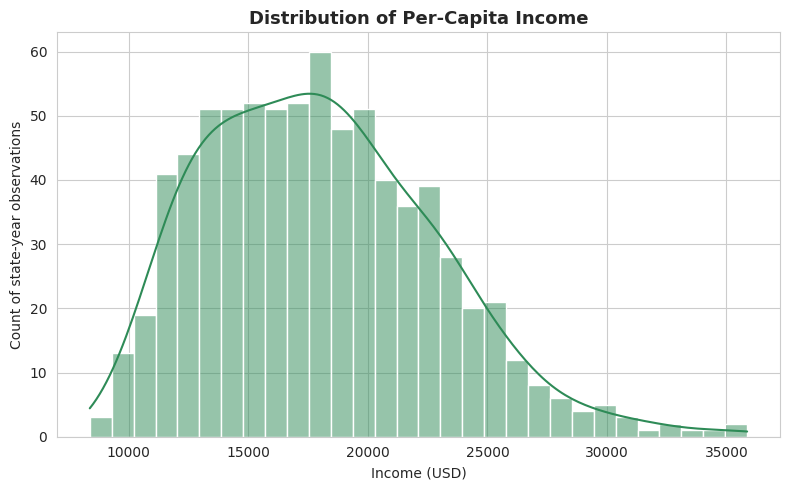

In [19]:
# 6.2 Distribution of per-capita income
fig, ax = plt.subplots()
sns.histplot(df["income"], bins=30, kde=True, color="seagreen", ax=ax)
ax.set_title("Distribution of Per-Capita Income")
ax.set_xlabel("Income (USD)")
ax.set_ylabel("Count of state-year observations")
plt.tight_layout()
plt.show()


/tmp/ipykernel_640/155891137.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="enforce", data=df, order=["no", "secondary", "primary"], palette="viridis", ax=ax)


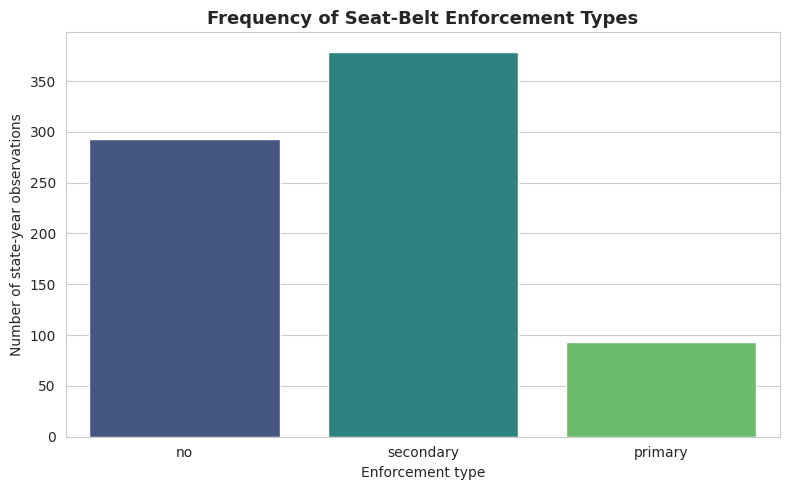

In [20]:
# 6.3 Frequency of seat-belt law enforcement types
fig, ax = plt.subplots()
sns.countplot(x="enforce", data=df, order=["no", "secondary", "primary"], palette="viridis", ax=ax)
ax.set_title("Frequency of Seat-Belt Enforcement Types")
ax.set_xlabel("Enforcement type")
ax.set_ylabel("Number of state-year observations")
plt.tight_layout()
plt.show()


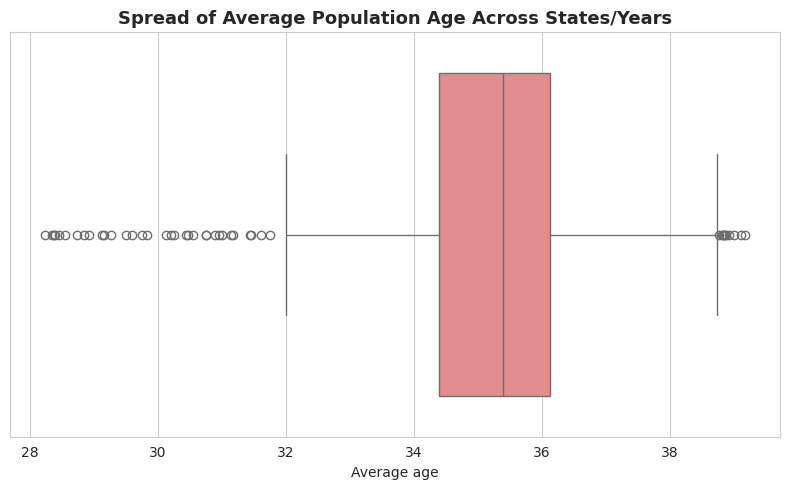

In [21]:
# 6.4 Distribution of average population age (bonus 4th univariate plot)
fig, ax = plt.subplots()
sns.boxplot(x=df["age"], color="lightcoral", ax=ax)
ax.set_title("Spread of Average Population Age Across States/Years")
ax.set_xlabel("Average age")
plt.tight_layout()
plt.show()


**Univariate insights:**
- The fatality rate distribution is **right-skewed** — most state-years cluster at
  lower fatality rates, with a long tail of higher-fatality observations (mostly
  earlier years / less-regulated states).
- Income is also right-skewed, consistent with general income-distribution patterns
  and the fact that income rises over the 15-year study window (inflation + growth).
- `secondary` enforcement is the most common law type in this dataset, followed by
  `no` law, with `primary` enforcement being comparatively rare — reflecting that most
  US states adopted the weaker "secondary enforcement" seat-belt laws.


## 7. Bivariate Analysis

Examining the relationship between pairs of variables.


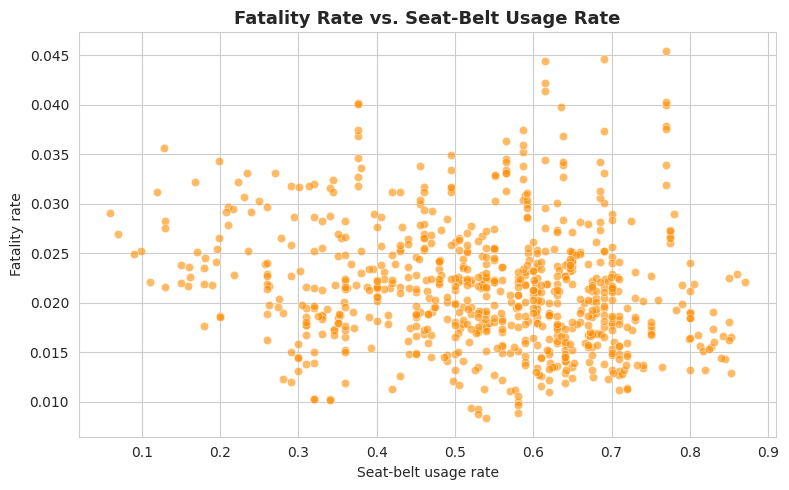

In [22]:
# 7.1 Fatality rate vs. seat-belt usage rate
fig, ax = plt.subplots()
sns.scatterplot(x="seatbelt", y="fatalities", data=df, alpha=0.6, color="darkorange", ax=ax)
ax.set_title("Fatality Rate vs. Seat-Belt Usage Rate")
ax.set_xlabel("Seat-belt usage rate")
ax.set_ylabel("Fatality rate")
plt.tight_layout()
plt.show()


/tmp/ipykernel_640/345603554.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="enforce", y="fatalities", data=df, order=["no", "secondary", "primary"],


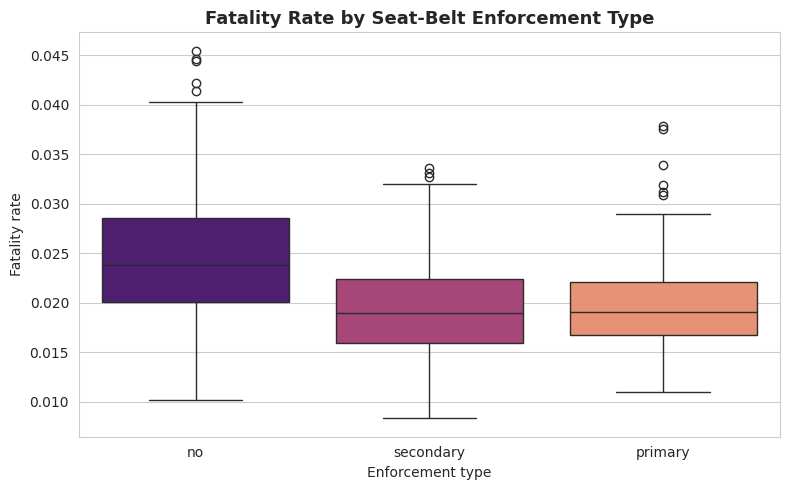

In [23]:
# 7.2 Fatality rate across enforcement types
fig, ax = plt.subplots()
sns.boxplot(x="enforce", y="fatalities", data=df, order=["no", "secondary", "primary"],
            palette="magma", ax=ax)
ax.set_title("Fatality Rate by Seat-Belt Enforcement Type")
ax.set_xlabel("Enforcement type")
ax.set_ylabel("Fatality rate")
plt.tight_layout()
plt.show()


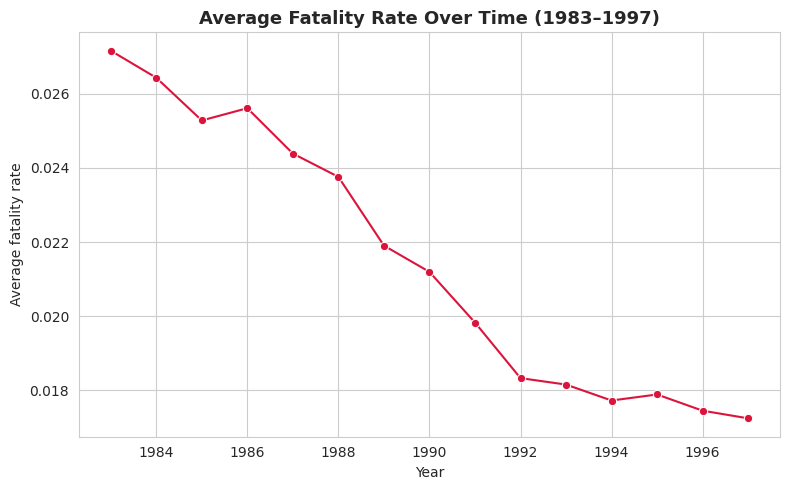

In [24]:
# 7.3 Trend of average fatality rate over the years (time-series line)
yearly_avg = df.groupby("year")["fatalities"].mean().reset_index()
fig, ax = plt.subplots()
sns.lineplot(x="year", y="fatalities", data=yearly_avg, marker="o", color="crimson", ax=ax)
ax.set_title("Average Fatality Rate Over Time (1983–1997)")
ax.set_xlabel("Year")
ax.set_ylabel("Average fatality rate")
plt.tight_layout()
plt.show()


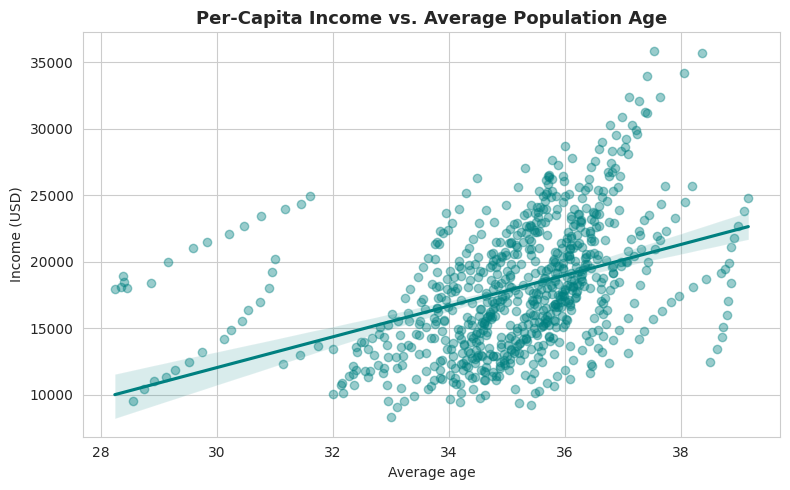

In [25]:
# 7.4 Income vs. age (bonus 4th bivariate plot)
fig, ax = plt.subplots()
sns.regplot(x="age", y="income", data=df, scatter_kws={"alpha": 0.4}, color="teal", ax=ax)
ax.set_title("Per-Capita Income vs. Average Population Age")
ax.set_xlabel("Average age")
ax.set_ylabel("Income (USD)")
plt.tight_layout()
plt.show()


**Bivariate insights:**
- There is a **negative relationship** between seat-belt usage and fatality rate —
  states/years with higher seat-belt usage tend to have lower fatality rates, which
  matches real-world road-safety expectations.
- Fatality rate is **lowest under `primary` enforcement**, higher under `secondary`,
  and highest where there is **no law** — enforcement strength appears to matter.
- The **year-over-year trend is clearly declining**, reflecting the combined effect of
  seat-belt laws, airbags, and other safety improvements introduced during this period.


## 8. Multivariate Analysis

Examining interactions between three or more variables at once.


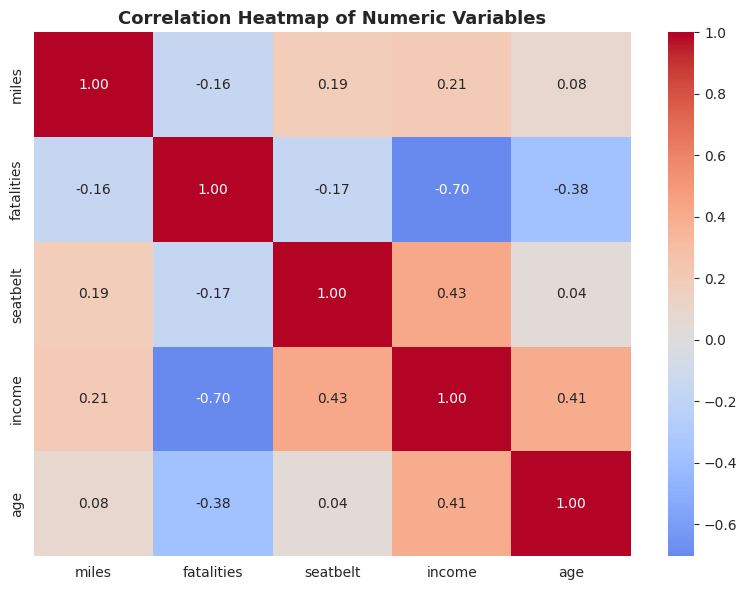

In [26]:
# 8.1 Correlation heatmap across all numeric variables
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[["miles", "fatalities", "seatbelt", "income", "age"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()


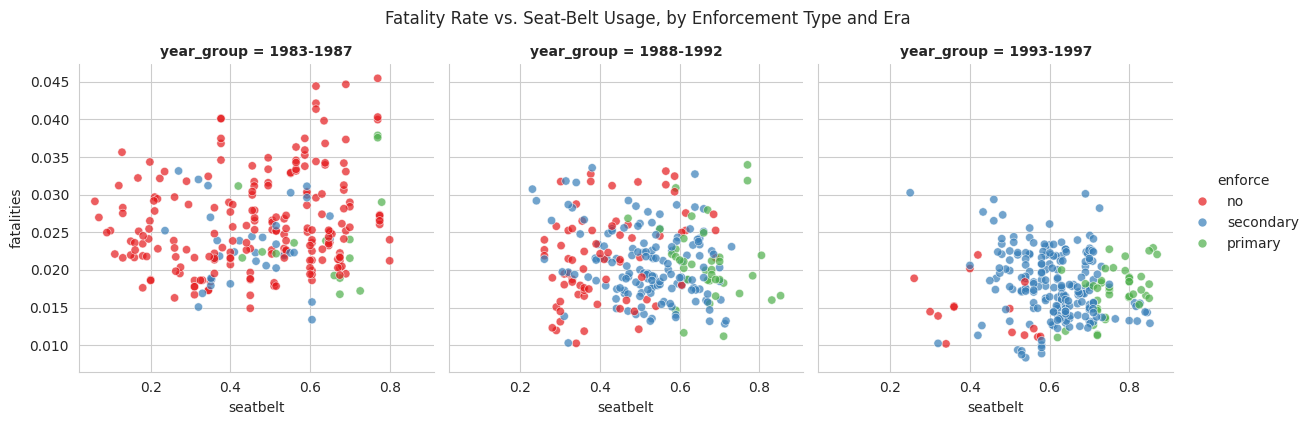

In [27]:
# 8.2 Fatality rate vs seatbelt usage, colored by enforcement type, faceted by era
g = sns.relplot(
    data=df, x="seatbelt", y="fatalities",
    hue="enforce", hue_order=["no", "secondary", "primary"],
    col="year_group", kind="scatter", alpha=0.7, height=4, aspect=1,
    palette="Set1"
)
g.fig.suptitle("Fatality Rate vs. Seat-Belt Usage, by Enforcement Type and Era", y=1.05)
plt.show()


/tmp/ipykernel_640/2631596762.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["income_level", "enforce"])["fatalities"].mean().reset_index()


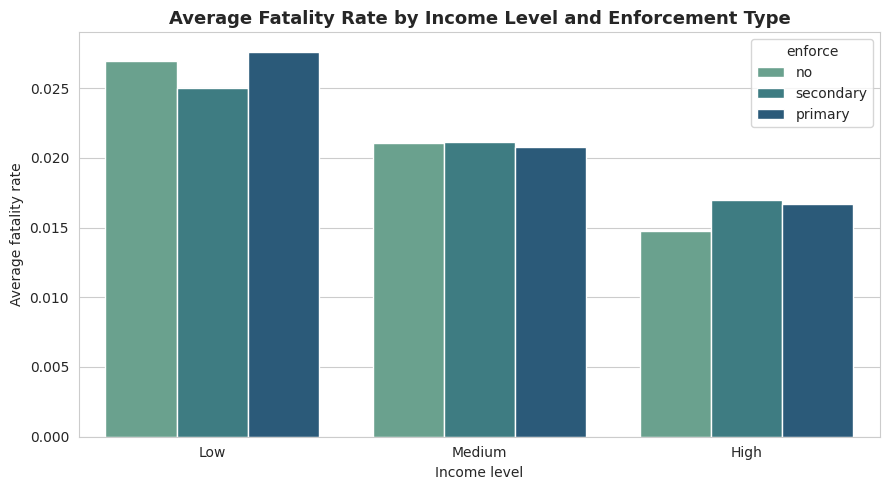

In [28]:
# 8.3 Average fatality rate by income level and enforcement type (grouped bars)
grouped = df.groupby(["income_level", "enforce"])["fatalities"].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=grouped, x="income_level", y="fatalities", hue="enforce",
            hue_order=["no", "secondary", "primary"], palette="crest", ax=ax)
ax.set_title("Average Fatality Rate by Income Level and Enforcement Type")
ax.set_xlabel("Income level")
ax.set_ylabel("Average fatality rate")
plt.tight_layout()
plt.show()


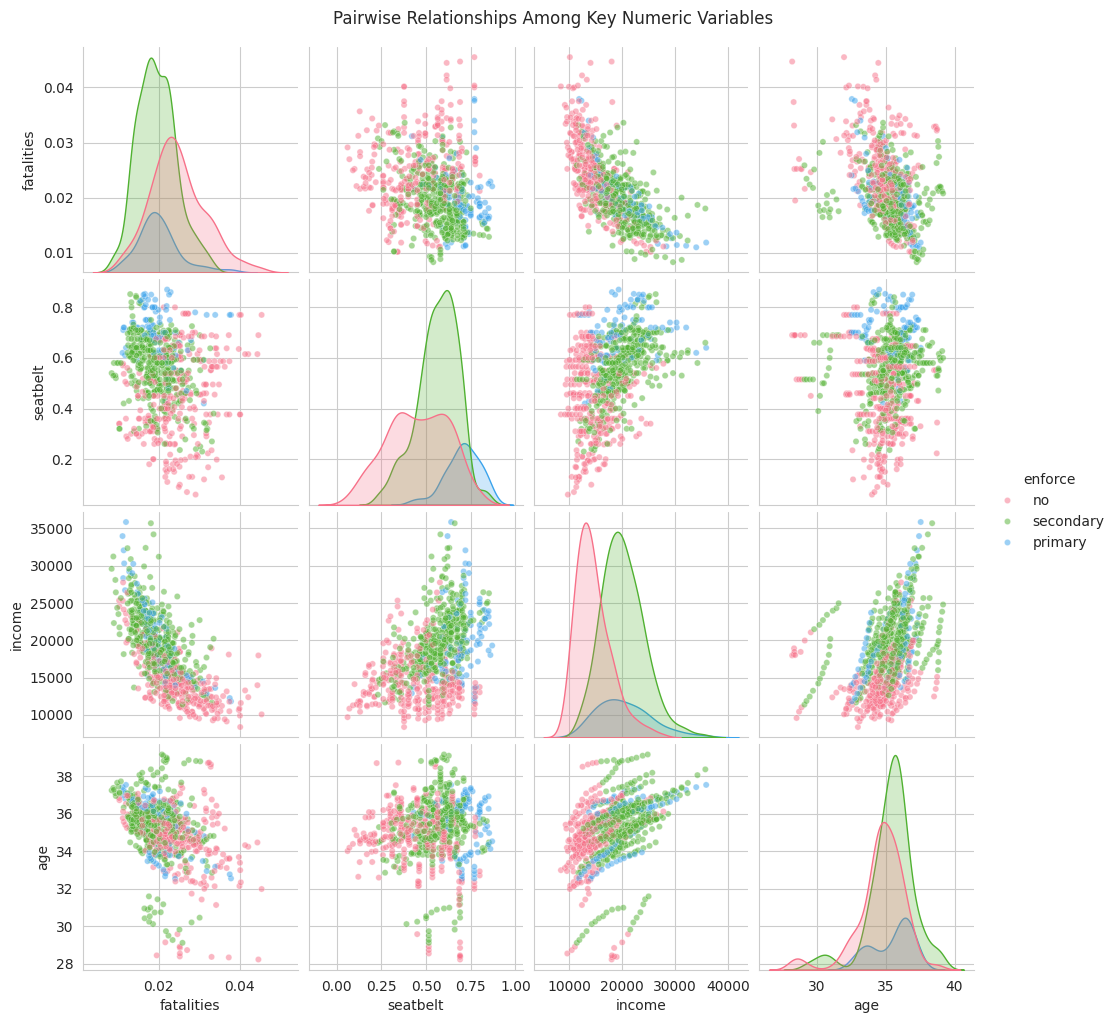

In [29]:
# 8.4 Pairwise relationships across key numeric variables, colored by enforcement (bonus 4th)
sample_cols = ["fatalities", "seatbelt", "income", "age", "enforce"]
g2 = sns.pairplot(df[sample_cols], hue="enforce", hue_order=["no", "secondary", "primary"],
                   palette="husl", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 20})
g2.fig.suptitle("Pairwise Relationships Among Key Numeric Variables", y=1.02)
plt.show()


**Multivariate insights:**
- The correlation heatmap confirms `seatbelt` usage is **negatively correlated** with
  `fatalities`, while `income` correlates positively with `seatbelt` usage — wealthier
  states/years tend to have both higher seat-belt compliance and lower fatality rates.
- Faceting by era shows the seat-belt usage vs. fatality relationship **strengthens
  over time**: in 1983–1987 usage is uniformly low and law type barely varies fatality
  outcomes, whereas by 1993–1997 states with `primary` enforcement cluster at high
  usage and low fatality rates.
- Combining income level with enforcement type shows that **enforcement type has a
  visible effect within every income band**, suggesting the law's effect isn't simply
  a proxy for wealth — both factors act somewhat independently on fatality rate.

---
## Summary


**Key finding:** Traffic fatality rates declined steadily across US states from 1983
to 1997, and this decline is closely tied to rising seat-belt usage, which itself
climbed fastest in states with stronger (`primary`) enforcement laws.
